# Практические задания 1-5: предиктивная аналитика ветроэнергетической установки

Этот ноутбук является самостоятельным продолжением `Wind_Turbine_Tutorial_RU_ML.ipynb`.
Он использует CSV-файлы из папки `dataset`: `scada_data.csv`, `status_data.csv`, `fault_data.csv`.

Сначала повторяется минимальная подготовка данных из основного ноутбука: парсинг дат, пересечение временных периодов, разметка SCADA через `merge_asof`, удаление leakage-признаков и подготовка обучающей таблицы. После этого решаются задания 1-5.

## Практические задания

1. **Задание 1.** Постройте boxplot для канала `WEC: ava. reactive Power` в разрезе типов отказов. Что вы видите для класса `EF`?
2. **Задание 2.** Замените `SMOTE` на `BorderlineSMOTE` в pipeline. Сравните метрики до и после.
3. **Задание 3.** Постройте feature importance для тюнингованной модели LightGBM (`grid.best_estimator_.named_steps['lgbmclassifier'].feature_importances_`). Какие 5 признаков наиболее важны?
4. **Задание 4.** Реализуйте временную валидацию через `TimeSeriesSplit` вместо `StratifiedKFold`. Как изменились метрики? Объясните разницу.
5. **Задание 5.** Постройте PCA-проекцию признаков SCADA в 2D, раскрасьте точки по типу отказа. Видна ли визуальная разделимость классов?

## 0. Установка и импорт библиотек

В Google Colab сначала раскомментируйте ячейку установки. При локальном запуске зависимости можно поставить командой `python -m pip install -r requirements.txt`.

In [1]:
# Для Google Colab раскомментируйте строку ниже:\n
# !pip install -q imbalanced-learn lightgbm\n

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.decomposition import PCA

from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
RANDOM_STATE = 42

## 1. Загрузка данных из `dataset`

Код ищет папку `dataset` рядом с ноутбуком, в текущей рабочей директории или в `/content/dataset` для Colab.

In [ ]:
def find_data_dir():
    candidates = [
        Path("dataset"),
        Path("my collabs/part1/dataset"),
        Path("/content/dataset"),
    ]
    for candidate in candidates:
        if (candidate / "scada_data.csv").exists():
            return candidate
    raise FileNotFoundError("Не найдена папка dataset со scada_data.csv, status_data.csv, fault_data.csv")


DATA_DIR = find_data_dir()
print(f"Используем данные из: {DATA_DIR.resolve()}")

scada = pd.read_csv(DATA_DIR / "scada_data.csv")
status = pd.read_csv(DATA_DIR / "status_data.csv")
faults = pd.read_csv(DATA_DIR / "fault_data.csv")

scada["DateTime"] = pd.to_datetime(scada["DateTime"], errors="coerce")
status["Time"] = pd.to_datetime(status["Time"], dayfirst=True, errors="coerce")
faults["DateTime"] = pd.to_datetime(faults["DateTime"], errors="coerce")

scada = scada.sort_values("DateTime").reset_index(drop=True)
status = status.sort_values("Time").reset_index(drop=True)
faults = faults.sort_values("DateTime").reset_index(drop=True)

print("SCADA :", scada.shape)
print("Status:", status.shape)
print("Faults:", faults.shape)

Используем данные из: D:\ИТМО\Семестр 2\СистемыАльтерЭнерг\my collabs\part1\dataset


KeyboardInterrupt: 

## 2. Разметка SCADA по журналу отказов

SCADA записывается регулярно, а журнал отказов содержит отдельные события. Поэтому используем `pandas.merge_asof`: для каждой SCADA-записи ищется ближайший отказ в окне 10 минут. Если рядом отказа нет, ставится `NF` — нормальный режим.

In [4]:
common_start = max(scada["DateTime"].min(), status["Time"].min(), faults["DateTime"].min())
common_end = min(scada["DateTime"].max(), status["Time"].max(), faults["DateTime"].max())
in_common = (scada["DateTime"] >= common_start) & (scada["DateTime"] <= common_end)

scada_common = scada.loc[in_common].sort_values("DateTime").reset_index(drop=True)
faults_sorted = faults.sort_values("DateTime").reset_index(drop=True)

df_combine = pd.merge_asof(
    scada_common,
    faults_sorted[["DateTime", "Fault"]],
    on="DateTime",
    direction="nearest",
    tolerance=pd.Timedelta(minutes=10),
)
df_combine["Fault"] = df_combine["Fault"].fillna("NF")

print(f"Общий период: {common_start} ... {common_end}")
print(f"Размер объединенной таблицы: {df_combine.shape}")
print(df_combine["Fault"].value_counts())

Общий период: 2014-05-14 14:39:44 ... 2015-01-15 23:09:20
Размер объединенной таблицы: (35168, 67)
Fault
NF    34610
FF      210
EF      210
AF       79
GF       46
MF       13
Name: count, dtype: int64


## 3. Подготовка признаков

Класс `NF` сильно доминирует, поэтому оставляем 300 случайных нормальных записей и все записи с отказами. Затем удаляем признаки с возможной утечкой: время, мощность, выработку, часы работы, скорость ветра и служебные поля.

In [5]:
df_nf = df_combine[df_combine["Fault"] == "NF"].sample(300, random_state=RANDOM_STATE)
df_fault = df_combine[df_combine["Fault"] != "NF"]
df_balanced = pd.concat([df_nf, df_fault], axis=0).reset_index(drop=True)

drop_cols = [
    "DateTime", "Time", "Error",
    "WEC: ava. windspeed", "WEC: max. windspeed", "WEC: min. windspeed",
    "WEC: ava. Power", "WEC: max. Power", "WEC: min. Power",
    "WEC: ava. available P from wind",
    "WEC: ava. available P technical reasons",
    "WEC: ava. Available P force majeure reasons",
    "WEC: ava. Available P force external reasons",
    "WEC: Operating Hours", "WEC: Production kWh", "WEC: Production minutes",
    "ws_bin",
]
drop_cols = [c for c in drop_cols if c in df_balanced.columns]

train_df = df_balanced.drop(columns=drop_cols).dropna().reset_index(drop=True)
X = train_df.drop(columns=["Fault"])
y = train_df["Fault"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("После подвыборки NF:")
print(df_balanced["Fault"].value_counts())
print(f"Итоговая таблица: {train_df.shape}")
print(f"Признаков: {X.shape[1]}")

После подвыборки NF:
Fault
NF    300
FF    210
EF    210
AF     79
GF     46
MF     13
Name: count, dtype: int64
Итоговая таблица: (858, 51)
Признаков: 50


In [6]:
def make_lgbm_pipeline(sampler):
    return make_pipeline(
        sampler,
        StandardScaler(),
        LGBMClassifier(
            random_state=RANDOM_STATE,
            verbose=-1,
            n_estimators=80,
            num_leaves=12,
            reg_alpha=1,
            reg_lambda=1,
        ),
    )


scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}
stratkfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Задание 1. Boxplot реактивной мощности

Строим boxplot для `WEC: ava. reactive Power` по классам. Этот канал важен для электрических режимов: реактивная мощность часто меняется при проблемах возбуждения и сети.

In [ ]:
class_order = [c for c in ["NF", "FF", "EF", "AF", "GF", "MF"] if c in df_combine["Fault"].unique()]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_combine,
    x="Fault",
    y="WEC: ava. reactive Power",
    order=class_order,
    palette="Set2",
)
plt.title("WEC: ava. reactive Power по типам отказов")
plt.xlabel("Тип отказа / режим")
plt.ylabel("Средняя реактивная мощность")
plt.tight_layout()
plt.show()

reactive_summary = df_combine.groupby("Fault")["WEC: ava. reactive Power"].describe().round(2)
reactive_summary.loc[class_order]

**Вывод по заданию 1.** Для класса `EF` распределение реактивной мощности заметно сдвинуто вверх: медиана около 204, среднее около 206. Для сравнения, у `NF` медиана около 47, у `FF` около 70, у `GF` медиана равна 0. Это согласуется с физическим смыслом `EF` как отказа возбуждения.

## Задание 2. SMOTE против BorderlineSMOTE

`SMOTE` генерирует синтетические точки между объектами миноритарного класса. `BorderlineSMOTE` делает акцент на объектах около границы классов.

In [ ]:
def evaluate_pipeline(name, pipe):
    cv_scores = cross_validate(pipe, X_train, y_train, cv=stratkfold, scoring=scoring, n_jobs=1)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    test_scores = {
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, pred, average="macro"),
    }
    row = {"model": name}
    for metric in test_scores:
        row[f"cv_{metric}"] = cv_scores[f"test_{metric}"].mean()
        row[f"test_{metric}"] = test_scores[metric]
    return row, pred


smote_pipe = make_lgbm_pipeline(SMOTE(random_state=RANDOM_STATE, k_neighbors=3))
borderline_pipe = make_lgbm_pipeline(BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=3))

smote_row, y_pred_smote = evaluate_pipeline("SMOTE", smote_pipe)
borderline_row, y_pred_borderline = evaluate_pipeline("BorderlineSMOTE", borderline_pipe)

comparison = pd.DataFrame([smote_row, borderline_row]).set_index("model").round(4)
comparison

,cv_accuracy,test_accuracy,cv_precision_macro,test_precision_macro,cv_recall_macro,test_recall_macro,cv_f1_macro,test_f1_macro
model,,,,,,,,
SMOTE,0.8333,0.8721,0.8071,0.8531,0.7836,0.9009,0.7894,0.8684
BorderlineSMOTE,0.8450,0.8566,0.7987,0.8527,0.7780,0.8376,0.7834,0.8416


In [ ]:
print("SMOTE classification report:")
print(classification_report(y_test, y_pred_smote, zero_division=0))

print("BorderlineSMOTE classification report:")
print(classification_report(y_test, y_pred_borderline, zero_division=0))

SMOTE classification report:
              precision    recall  f1-score   support

          AF       0.81      0.88      0.84        24
          EF       0.78      0.95      0.86        63
          FF       0.93      0.79      0.85        63
          GF       1.00      0.93      0.96        14
          MF       0.67      1.00      0.80         4
          NF       0.94      0.86      0.90        90

    accuracy                           0.87       258
   macro avg       0.85      0.90      0.87       258
weighted avg       0.88      0.87      0.87       258

BorderlineSMOTE classification report:
              precision    recall  f1-score   support

          AF       0.86      0.75      0.80        24
          EF       0.76      0.95      0.85        63
          FF       0.92      0.78      0.84        63
          GF       0.93      0.93      0.93        14
          MF       0.75      0.75      0.75         4
          NF       0.90      0.87      0.88        90

    accur

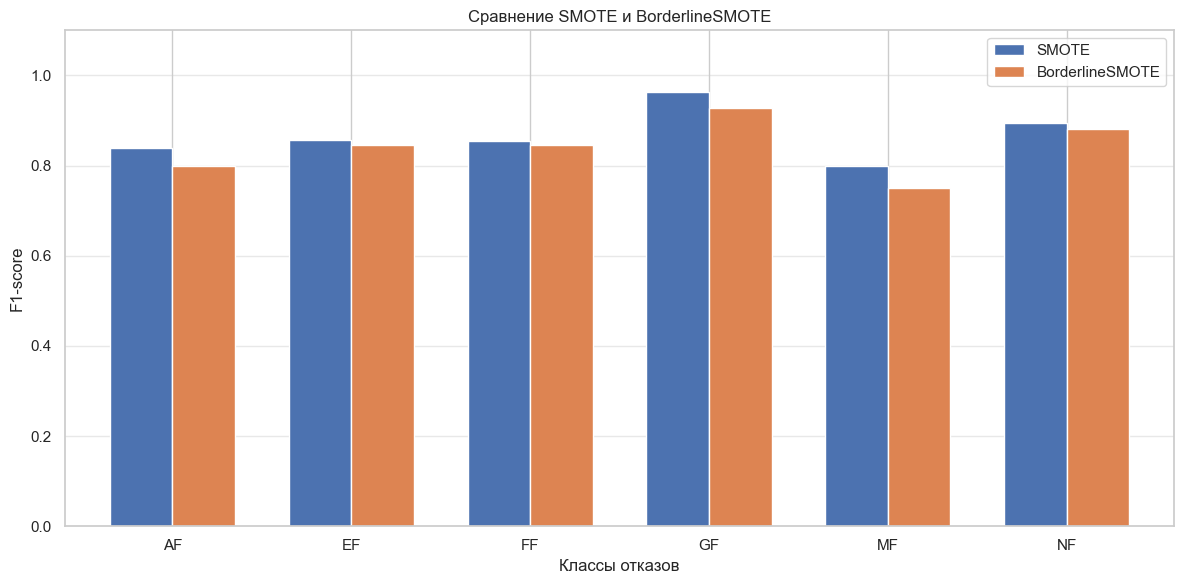

,SMOTE,BorderlineSMOTE
AF,0.8400,0.8000
EF,0.8571,0.8451
FF,0.8547,0.8448
GF,0.9630,0.9286
MF,0.8000,0.7500
NF,0.8953,0.8814


In [ ]:
# График сравнения F1-score по классам для SMOTE и BorderlineSMOTE
smote_report = classification_report(y_test, y_pred_smote, output_dict=True, zero_division=0)
borderline_report = classification_report(y_test, y_pred_borderline, output_dict=True, zero_division=0)

f1_classes = [cls for cls in ["AF", "EF", "FF", "GF", "MF", "NF"] if cls in smote_report and cls in borderline_report]
f1_compare = pd.DataFrame({
    "SMOTE": [smote_report[cls]["f1-score"] for cls in f1_classes],
    "BorderlineSMOTE": [borderline_report[cls]["f1-score"] for cls in f1_classes],
}, index=f1_classes)

ax = f1_compare.plot(kind="bar", figsize=(12, 6), width=0.7)
ax.set_title("Сравнение SMOTE и BorderlineSMOTE")
ax.set_xlabel("Классы отказов")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.1)
ax.grid(True, axis="y", alpha=0.45)
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

f1_compare.round(4)

**Вывод по заданию 2.** На локальном прогоне обычный `SMOTE` дал test macro F1 около 0.868, а `BorderlineSMOTE` около 0.842. BorderlineSMOTE не обязан всегда улучшать качество: если границы классов шумные или классы физически пересекаются, усиление пограничных объектов может добавить неоднозначных синтетических примеров.

## Задание 3. Feature importance тюнингованной LightGBM

Выполним небольшой `GridSearchCV`, затем достанем обученный классификатор из pipeline через `grid.best_estimator_.named_steps['lgbmclassifier']`.

In [ ]:
base_grid_pipe = make_pipeline(
    SMOTE(random_state=RANDOM_STATE, k_neighbors=3),
    StandardScaler(),
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
)

param_grid = {
    "lgbmclassifier__n_estimators": [16, 24],
    "lgbmclassifier__num_leaves": [6, 8],
    "lgbmclassifier__reg_alpha": [1, 1.5],
    "lgbmclassifier__reg_lambda": [1, 1.5],
    "lgbmclassifier__boosting_type": ["gbdt"],
}

grid = GridSearchCV(
    base_grid_pipe,
    param_grid=param_grid,
    cv=stratkfold,
    scoring="f1_macro",
    n_jobs=1,
    verbose=0,
)
grid.fit(X_train, y_train)

print("Лучшие параметры:")
for key, value in grid.best_params_.items():
    print(f"{key}: {value}")
print(f"Лучший CV macro F1: {grid.best_score_:.4f}")

best_pred = grid.predict(X_test)
print(f"Test macro F1: {f1_score(y_test, best_pred, average='macro'):.4f}")

Лучшие параметры:
lgbmclassifier__boosting_type: gbdt
lgbmclassifier__n_estimators: 24
lgbmclassifier__num_leaves: 8
lgbmclassifier__reg_alpha: 1
lgbmclassifier__reg_lambda: 1.5
Лучший CV macro F1: 0.7590
Test macro F1: 0.7823


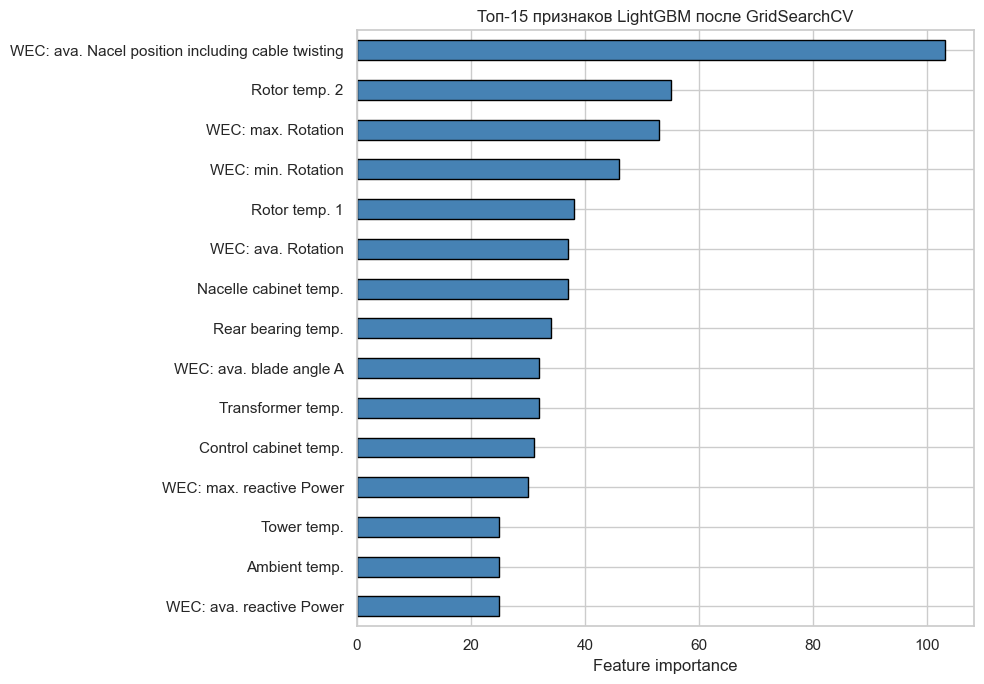

Топ-5 признаков:
WEC: ava. Nacel position including cable twisting    103
Rotor temp. 2                                         55
WEC: max. Rotation                                    53
WEC: min. Rotation                                    46
Rotor temp. 1                                         38


In [ ]:
best_lgbm = grid.best_estimator_.named_steps["lgbmclassifier"]
importance = pd.Series(best_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top15 = importance.head(15)
plt.figure(figsize=(10, 7))
top15[::-1].plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Топ-15 признаков LightGBM после GridSearchCV")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

print("Топ-5 признаков:")
print(importance.head(5).to_string())

**Вывод по заданию 3.** В локальном прогоне топ-5 получился таким: `WEC: ava. Nacel position including cable twisting`, `Rotor temp. 2`, `WEC: max. Rotation`, `WEC: min. Rotation`, `Rotor temp. 1`. Это физически правдоподобно: положение гондолы, обороты и температуры ротора связаны с режимом работы и состоянием электромеханической части установки.

## Задание 4. Временная валидация через TimeSeriesSplit

`StratifiedKFold` перемешивает данные и проверяет модель на случайных фолдах. Для временных рядов это может быть слишком оптимистично. `TimeSeriesSplit` сохраняет порядок: обучаемся на прошлом, проверяемся на будущем.

In [ ]:
train_ts = df_balanced.sort_values("DateTime").drop(columns=drop_cols).dropna().reset_index(drop=True)
X_ts = train_ts.drop(columns=["Fault"])
y_ts = train_ts["Fault"]

time_cv = TimeSeriesSplit(n_splits=5)
ts_rows = []

for fold, (train_idx, test_idx) in enumerate(time_cv.split(X_ts), start=1):
    X_tr, X_val = X_ts.iloc[train_idx], X_ts.iloc[test_idx]
    y_tr, y_val = y_ts.iloc[train_idx], y_ts.iloc[test_idx]

    model = grid.best_estimator_
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)

    ts_rows.append({
        "fold": fold,
        "train_classes": dict(y_tr.value_counts()),
        "test_classes": dict(y_val.value_counts()),
        "accuracy": accuracy_score(y_val, pred),
        "precision_macro": precision_score(y_val, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, pred, average="macro"),
    })

ts_result = pd.DataFrame(ts_rows)
display(ts_result[["fold", "accuracy", "precision_macro", "recall_macro", "f1_macro"]].round(4))
print("Средние метрики TimeSeriesSplit:")
print(ts_result[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].mean().round(4))

print("\nРаспределение классов по фолдам:")
for row in ts_rows:
    print(f"fold {row['fold']}: train={row['train_classes']} | test={row['test_classes']}")

,fold,accuracy,precision_macro,recall_macro,f1_macro
0,1,0.6573,0.3616,0.4125,0.3549
1,2,0.1608,0.3113,0.1388,0.1421
2,3,0.5664,0.3714,0.2970,0.2986
3,4,0.3497,0.2524,0.4150,0.3095
4,5,0.3986,0.2408,0.3047,0.2363


Средние метрики TimeSeriesSplit:
accuracy          0.4266
precision_macro   0.3075
recall_macro      0.3136
f1_macro          0.2683
dtype: float64

Распределение классов по фолдам:
fold 1: train={'NF': np.int64(90), 'AF': np.int64(26), 'EF': np.int64(10), 'GF': np.int64(6), 'MF': np.int64(6), 'FF': np.int64(5)} | test={'NF': np.int64(85), 'AF': np.int64(47), 'EF': np.int64(9), 'FF': np.int64(2)}
fold 2: train={'NF': np.int64(175), 'AF': np.int64(73), 'EF': np.int64(19), 'FF': np.int64(7), 'GF': np.int64(6), 'MF': np.int64(6)} | test={'EF': np.int64(80), 'NF': np.int64(31), 'FF': np.int64(21), 'MF': np.int64(7), 'GF': np.int64(4)}
fold 3: train={'NF': np.int64(206), 'EF': np.int64(99), 'AF': np.int64(73), 'FF': np.int64(28), 'MF': np.int64(13), 'GF': np.int64(10)} | test={'EF': np.int64(94), 'NF': np.int64(30), 'FF': np.int64(10), 'GF': np.int64(9)}
fold 4: train={'NF': np.int64(236), 'EF': np.int64(193), 'AF': np.int64(73), 'FF': np.int64(38), 'GF': np.int64(19), 'MF': np.int64(13)} |

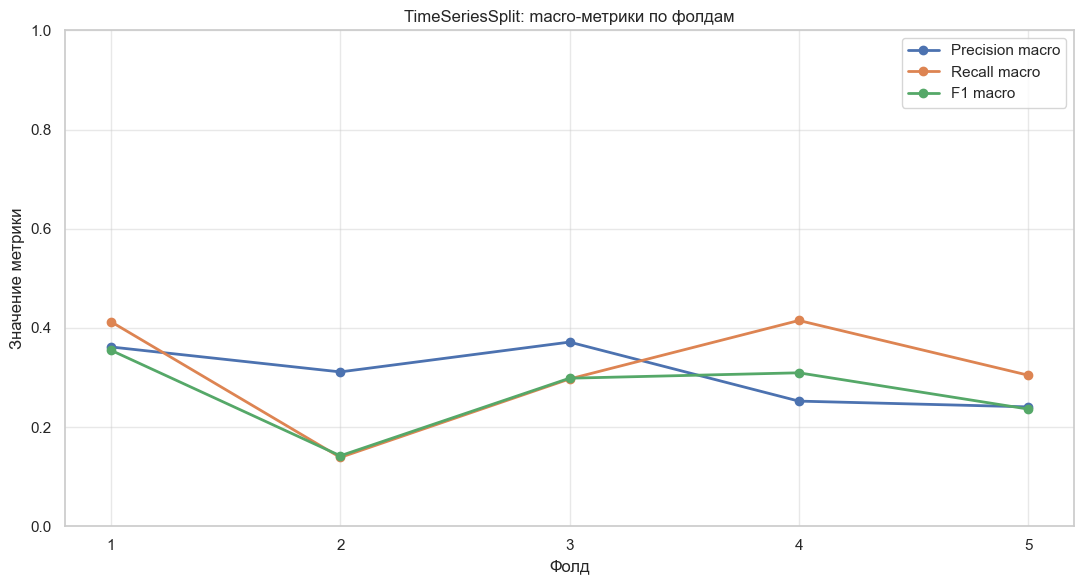

,Среднее по TimeSeriesSplit
precision_macro,0.3075
recall_macro,0.3136
f1_macro,0.2683


In [ ]:
# График трех macro-метрик по фолдам TimeSeriesSplit
macro_cols = ["precision_macro", "recall_macro", "f1_macro"]
macro_by_fold = ts_result.set_index("fold")[macro_cols]

ax = macro_by_fold.plot(marker="o", figsize=(11, 6), linewidth=2)
ax.set_title("TimeSeriesSplit: macro-метрики по фолдам")
ax.set_xlabel("Фолд")
ax.set_ylabel("Значение метрики")
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.45)
ax.legend(["Precision macro", "Recall macro", "F1 macro"])
plt.xticks(macro_by_fold.index)
plt.tight_layout()
plt.show()

macro_by_fold.mean().rename("Среднее по TimeSeriesSplit").to_frame().round(4)

**Вывод по заданию 4.** В локальном прогоне средний macro F1 на `TimeSeriesSplit` был около 0.268 против заметно более высоких значений при случайной стратифицированной проверке. Временная проверка сложнее и ближе к реальной эксплуатации: модель учится на прошлом и сталкивается с будущим распределением отказов.

## Задание 5. PCA-проекция SCADA-признаков в 2D

PCA сжимает многомерные признаки в две главные компоненты, которые сохраняют максимум линейной дисперсии. Это не классификатор, а способ посмотреть, есть ли грубая визуальная разделимость классов.

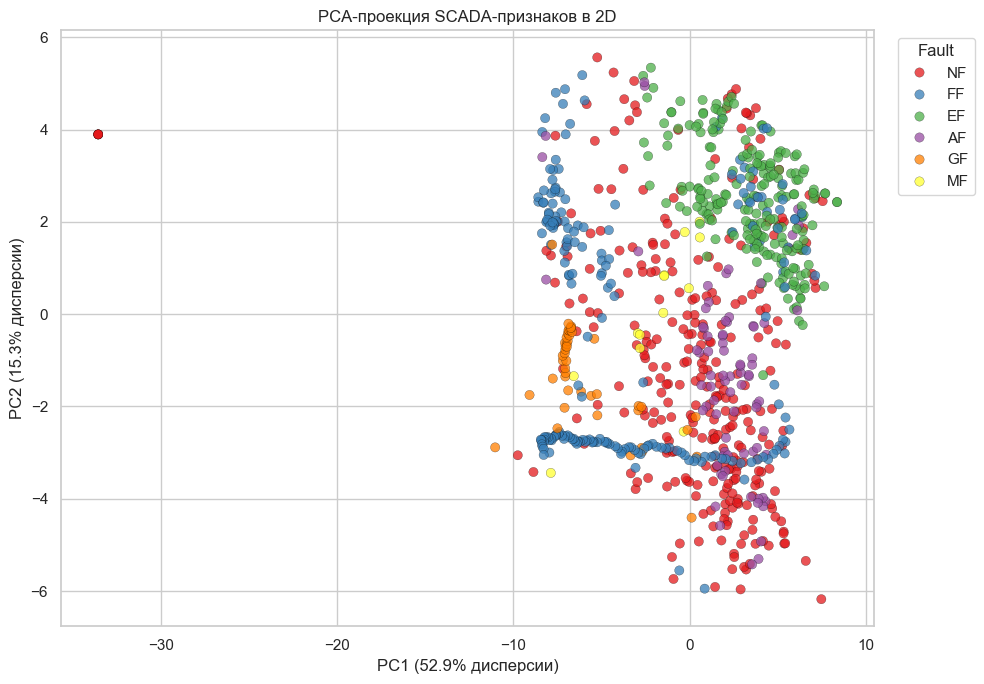

Доля объясненной дисперсии:
PC1   0.5291
PC2   0.1529
dtype: float64


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Fault": y.values,
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Fault",
    hue_order=class_order,
    palette="Set1",
    s=45,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.2,
)
plt.title("PCA-проекция SCADA-признаков в 2D")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% дисперсии)")
plt.legend(title="Fault", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Доля объясненной дисперсии:")
print(pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"]).round(4))

**Вывод по заданию 5.** Полной визуальной разделимости классов в 2D обычно не видно: облака `NF`, `FF`, `EF` и малые классы частично пересекаются. Это означает, что задача не сводится к простой линейной границе на двух компонентах; для устойчивой классификации нужны исходные многомерные признаки и нелинейная модель.

## Итог

Задания 1-5 показывают полный мини-пайплайн диагностики: инженерная визуализация канала, сравнение методов балансировки, интерпретация LightGBM, более честная временная валидация и PCA как быстрая проверка геометрии классов. Главный практический вывод: для временных рядов ВЭУ итоговое решение надо принимать по `TimeSeriesSplit` или разделению по датам и per-class метрикам, а не только по случайному среднему F1.